# Full Annotation Run: Agreement Ceiling + Task Pruning

1. **Human-human agreement** (ordinal Krippendorff's alpha + pairwise percent agreement, 50 items x 3 raters) — the ceiling any LLM-judge's human-AI agreement is measured against.
2. **Prune invalid tasks** where humans disagree widely (spread >= 2 on the 0-5 scale): if humans can't agree on a score, the item can't validate a judge.
3. Export the valid task set (`tasks_public.csv` minus the pruned task_ids) to `../data/valid_tasks_public.csv`.

In [1]:
import numpy as np
import pandas as pd

SCALE = list(range(0, 6))
K = len(SCALE)

df = pd.read_csv('full-annotator-scores.csv')
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

wide = df.pivot(index='task_id', columns='tagger_name', values='score')
RATERS = list(wide.columns)
M = wide.to_numpy(dtype=float)
n_units, R = M.shape
print(f'{n_units} units x {R} raters, scale 0-{K-1}, missing cells: {int(np.isnan(M).sum())}')

50 units x 3 raters, scale 0-5, missing cells: 0


---
## 1. Human-human agreement (the ceiling)

Same estimator as the pilot: ordinal Krippendorff's alpha with a percentile bootstrap CI over units. At n=50 the point estimate is informative, unlike the pilot's n=10.

In [2]:
def krippendorff_alpha_ordinal(matrix, scale=SCALE):
    """Krippendorff's alpha with the ordinal difference function. matrix = units x raters."""
    pos = {c: i for i, c in enumerate(scale)}
    k = len(scale)

    o = np.zeros((k, k))
    for row in matrix:
        vals = [v for v in row if not np.isnan(v)]
        m = len(vals)
        if m < 2:
            continue
        for a in vals:
            for b in vals:
                o[pos[a], pos[b]] += 1.0 / (m - 1)
        for a in vals:
            o[pos[a], pos[a]] -= 1.0 / (m - 1)

    n_c = o.sum(axis=1)
    n = n_c.sum()
    if n < 2:
        return np.nan

    d2 = np.zeros((k, k))
    for c in range(k):
        for kk in range(k):
            lo, hi = min(c, kk), max(c, kk)
            d2[c, kk] = (n_c[lo:hi + 1].sum() - (n_c[c] + n_c[kk]) / 2) ** 2

    D_o = (o * d2).sum() / n
    D_e = (np.outer(n_c, n_c) * d2).sum() / (n * (n - 1))
    return 1 - D_o / D_e


def alpha_with_ci(matrix, n_boot=5000, seed=0):
    a = krippendorff_alpha_ordinal(matrix)
    rng = np.random.default_rng(seed)
    n = matrix.shape[0]
    boot = np.array([krippendorff_alpha_ordinal(matrix[rng.integers(0, n, n)])
                     for _ in range(n_boot)])
    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return a, lo, hi, boot


alpha, lo, hi, boot = alpha_with_ci(M)
print(f'ordinal Krippendorff alpha = {alpha:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   (n={n_units}, R={R})')
print(f'P(alpha >= 0.80) = {np.mean(boot >= 0.80):.2f}   P(alpha >= 0.67) = {np.mean(boot >= 0.67):.2f}')

ordinal Krippendorff alpha = 0.775   95% CI [0.625, 0.874]   (n=50, R=3)
P(alpha >= 0.80) = 0.32   P(alpha >= 0.67) = 0.92


---
### 1a. Pairwise percent agreement

Raw (not chance-corrected) agreement, as an interpretable companion to alpha and a direct
ceiling for the same metrics computed human-vs-judge:
- `exact` — proportion of tasks where the pair gave identical scores
- `within_1` — proportion where the pair differed by at most 1 point

Mean over the 3 rater pairs is the headline number.

In [3]:
from itertools import combinations

def pairwise_agreement(scores):
    """Per-pair exact and +-1 agreement over a units x raters DataFrame, with a mean row."""
    p = pd.DataFrame([
        {'pair': f'{a} vs {b}',
         'exact': np.nanmean(scores[a] == scores[b]),
         'within_1': np.nanmean((scores[a] - scores[b]).abs() <= 1)}
        for a, b in combinations(scores.columns, 2)
    ]).set_index('pair')
    p.loc['— mean —'] = p.mean()
    return p


pairs = pairwise_agreement(wide)
print(f"mean pairwise exact agreement = {pairs.loc['— mean —', 'exact']:.3f}")
print(f"mean pairwise +-1 agreement   = {pairs.loc['— mean —', 'within_1']:.3f}")
pairs.round(3)

mean pairwise exact agreement = 0.580
mean pairwise +-1 agreement   = 0.933


,exact,within_1
pair,,
Jesi vs Rubayet Bushra,0.52,0.880
Jesi vs Yousuf,0.62,0.920
Rubayet Bushra vs Yousuf,0.60,1.000
— mean —,0.58,0.933


### 1b. Pairwise MSE (lower is better)

Mean squared error between graders over all 50 tasks, the squared-distance companion to the percent-agreement view above (it weighs the rare 2+ point disagreements more heavily). First table: MSE between each pair of graders. Second table: MSE between each grader and the mean of the other 2 — how far each grader sits from the rest of the panel.

In [4]:
mse_pairs = pd.DataFrame(index=RATERS, columns=RATERS, dtype=float)
mse_vs_rest = pd.Series(index=RATERS, dtype=float, name='MSE vs mean of other 2')
for r in RATERS:
    others = [o for o in RATERS if o != r]
    for o in others:
        mse_pairs.loc[r, o] = ((wide[r] - wide[o]) ** 2).mean()
    mse_vs_rest[r] = ((wide[r] - wide[others].mean(axis=1)) ** 2).mean()

display(mse_pairs.style.format('{:.2f}', na_rep=''))
mse_vs_rest.round(3).to_frame()

,Jesi,Rubayet Bushra,Yousuf
Jesi,,1.08,0.72
Rubayet Bushra,1.08,,0.40
Yousuf,0.72,0.40,


,MSE vs mean of other 2
Jesi,0.80
Rubayet Bushra,0.56
Yousuf,0.29


---
## 2. Prune invalid tasks (wide human disagreement)

A task is invalid when max - min score across the 3 raters >= 2: the raters do not share a reading of the item, so it cannot serve as a reference for judging an AI grader. Spread of 1 is ordinary adjacent-category noise on an ordinal scale and is kept.

In [5]:
SPREAD_CUT = 2

items = wide.copy()
items['median'] = np.nanmedian(M, axis=1)
items['spread'] = np.nanmax(M, axis=1) - np.nanmin(M, axis=1)
items['invalid'] = items['spread'] >= SPREAD_CUT

pruned = items[items['invalid']].sort_values('spread', ascending=False)
kept = items[~items['invalid']]
print(f'pruned {len(pruned)} / {n_units} tasks (spread >= {SPREAD_CUT}), {len(kept)} kept')
pruned

pruned 6 / 50 tasks (spread >= 2), 44 kept


tagger_name,Jesi,Rubayet Bushra,Yousuf,median,spread,invalid
task_id,,,,,,
T5-H3,1,5,4,4.0,4.0,True
T10-H1,4,2,3,3.0,2.0,True
T3-H3,3,5,5,5.0,2.0,True
T5-H1,2,0,0,0.0,2.0,True
T8-E2,3,5,5,5.0,2.0,True
T9-H3,0,2,1,1.0,2.0,True


In [6]:
# rater comments on the pruned tasks, for the write-up
notes = df.set_index(['task_id', 'tagger_name'])
for tid, row in pruned.iterrows():
    print('=' * 100)
    print(f'{tid}   median={row["median"]:.1f}  spread={int(row["spread"])}')
    for r in RATERS:
        print(f'  [{int(row[r])}] {r}: {notes.loc[(tid, r), "comments"]}')
    print()

T5-H3   median=4.0  spread=4
  [1] Jesi: Answers the question but the reasoning is fabricated
  [5] Rubayet Bushra: Relevant, correct verdict (No answer) and conclusion (test not reliable due to insufficient data).  All requested parts included. The agent's extra detail doesn't contradict the gold answer.
  [4] Yousuf: Correct direction and relevant but agent adding more information

T10-H1   median=3.0  spread=2
  [4] Jesi: Some of the numerical figures in the comparison point is inaccurate.
For the roadmap, there is no inclusion of numerical facts. It mentions suggestions not given in Gold answer
  [2] Rubayet Bushra: Relevant and accurate on overall sentiment and top 3 issues but the industry comparison as verdict is completely wrong. The agent states the difference is statistically significant when the gold states it is not (p=0.290), it also gives the wrong industry average. Counts for mentions also different from gold.
  [3] Yousuf: Right direction and relevant. But numbers are w

---
## 3. Ceiling on the kept set + export

Alpha and pairwise agreement recomputed on kept tasks only — these are the human-human ceilings the LLM-judge is compared against, since the judge will only be evaluated on these tasks. The valid task set — `tasks_public.csv` minus the pruned task_ids — is written to `../data/valid_tasks_public.csv`.

In [7]:
M_kept = kept[RATERS].to_numpy(dtype=float)
alpha_k, lo_k, hi_k, boot_k = alpha_with_ci(M_kept)
pairs_k = pairwise_agreement(kept[RATERS])

print(f'all {n_units} tasks   : alpha = {alpha:.3f}   95% CI [{lo:.3f}, {hi:.3f}]')
print(f'kept {len(kept)} tasks  : alpha = {alpha_k:.3f}   95% CI [{lo_k:.3f}, {hi_k:.3f}]   <- human-human ceiling')
print(f"\nkept-set mean pairwise exact agreement = {pairs_k.loc['— mean —', 'exact']:.3f}")
print(f"kept-set mean pairwise +-1 agreement   = {pairs_k.loc['— mean —', 'within_1']:.3f}")

# the benchmark task set with the invalid tasks removed
tasks_public = pd.read_csv('../data/tasks_public.csv')
valid = tasks_public[~tasks_public['task_id'].isin(pruned.index)]
assert len(valid) == len(tasks_public) - len(pruned)
valid.to_csv('../data/valid_tasks_public.csv', index=False)
print(f"\nwrote {len(valid)} of {len(tasks_public)} tasks to ../data/valid_tasks_public.csv")
valid.head()

all 50 tasks   : alpha = 0.775   95% CI [0.625, 0.874]
kept 44 tasks  : alpha = 0.830   95% CI [0.688, 0.907]   <- human-human ceiling

kept-set mean pairwise exact agreement = 0.636
kept-set mean pairwise +-1 agreement   = 1.000

wrote 44 of 50 tasks to ../data/valid_tasks_public.csv


,task_id,dataset,question
0,T1-E1,easy,What proportion of Banking reviews that mentio...
1,T1-E2,easy,What proportion of Fashion reviews that mentio...
2,T1-H1,hard,What proportion of Fashion reviews that mentio...
3,T1-H2,hard,What proportion of Price Comparison reviews th...
4,T1-H3,hard,What proportion of Ride Hailing reviews that m...


---
## 4. LLM-judge scores

Scores from the reference-based LLM judge (`python -m cx_agent_bench.run_judge`: Gemini 3.1 Pro via the gateway with the `vertex_location=global` override — the gateway's pinned region serves no gemini-3.x model — temperature 0.0), appended to the human annotation table. `judge_score` sits alongside the 3 raters' scores, the human median and spread for all 50 tasks. An earlier Gemini 2.5 Pro run is kept in `judge_scores_gemini-2.5-pro.csv`.

In [8]:
# the judge runs (equivalent to `python -m cx_agent_bench.run_judge --model ... --out ...`);
# ~50 gateway calls / ~$0.3-0.5 per model, so a run is skipped when its csv already exists
from pathlib import Path

from cx_agent_bench.run_judge import judge_one, make_client

JUDGE_RUNS = {
    'gemini-3.1-pro': ('vertex_ai/gemini-3.1-pro-preview', 'judge_scores.csv'),
    'kimi-k2-thinking': ('vertex_ai/moonshotai/kimi-k2-thinking-maas',
                         'judge_scores_kimi-k2-thinking.csv'),
}

answers = pd.read_csv('baseline_answers.csv', encoding='utf-8-sig')
client = None
for judge_name, (model, out) in JUDGE_RUNS.items():
    if Path(out).exists():
        print(f'{judge_name}: {out} exists, skipping the run')
        continue
    client = client or make_client()
    results = [judge_one(client, model, row) for _, row in answers.iterrows()]
    pd.DataFrame(results).to_csv(out, index=False, encoding='utf-8')
    print(f'{judge_name}: wrote {out}')

judge_scores = {name: pd.read_csv(out).set_index('task_id')['judge_score']
                for name, (model, out) in JUDGE_RUNS.items()}
assert all(s.notna().all() and len(s) == n_units for s in judge_scores.values())

gemini-3.1-pro: judge_scores.csv exists, skipping the run
kimi-k2-thinking: judge_scores_kimi-k2-thinking.csv exists, skipping the run


In [9]:
# gemini 3.1 pro judge scores
judge = pd.read_csv('judge_scores.csv').set_index('task_id')['judge_score']

scores = items.drop(columns='invalid').join(judge)
assert scores['judge_score'].notna().all(), 'missing judge scores'
print(f"judge mean = {scores['judge_score'].mean():.2f}   "
      f"human median mean = {scores['median'].mean():.2f}")
# with pd.option_context('display.max_rows', None):
#     display(scores)

judge mean = 4.00   human median mean = 3.74


### 4a. Judge mean scores and pairwise agreements with humans (higher is better)

In [10]:
# judge-vs-human agreement on the kept 44 tasks. 'pairwise' = mean agreement of the
# judge with each of the 3 raters, computed exactly like the human-human ceiling;
# 'vs median' = agreement with the per-task human median (an integer, since the
# median of 3 integer scores is one of them); 'alpha_vs_median' = ordinal
# Krippendorff's alpha over the (judge, median) pair, same estimator as section 1.
rows = []
for judge_name, j in judge_scores.items():
    jk = j.reindex(kept.index)
    rows.append({
        'judge': judge_name,
        'mean_score': jk.mean(),
        'pairwise_exact': np.mean([(jk == kept[r]).mean() for r in RATERS]),
        'pairwise_within1': np.mean([((jk - kept[r]).abs() <= 1).mean()
                                     for r in RATERS]),
        'vs_median_exact': (jk == kept['median']).mean(),
        'vs_median_within1': ((jk - kept['median']).abs() <= 1).mean(),
        'alpha_vs_median': krippendorff_alpha_ordinal(
            np.column_stack([jk, kept['median']])),
    })
rows.append({'judge': 'human-human (ceiling)',
             'mean_score': kept['median'].mean(),
             'pairwise_exact': pairs_k.loc['— mean —', 'exact'],
             'pairwise_within1': pairs_k.loc['— mean —', 'within_1'],
             'vs_median_exact': np.nan, 'vs_median_within1': np.nan,
             'alpha_vs_median': alpha_k})  # 3-rater alpha on the kept set

comparison = pd.DataFrame(rows).set_index('judge').sort_values(by='judge')
print(f'kept {len(kept)} tasks')
comparison.round(3)

kept 44 tasks


,mean_score,pairwise_exact,pairwise_within1,vs_median_exact,vs_median_within1,alpha_vs_median
judge,,,,,,
gemini-3.1-pro,4.114,0.606,0.947,0.614,0.977,0.671
human-human (ceiling),3.841,0.636,1.000,NaN,NaN,0.830
kimi-k2-thinking,3.818,0.636,0.977,0.659,0.977,0.774


### 4b. Judge MSE against human graders and grader means (lower is better)

Mean squared error of each judge's scores against every human reference on the kept 44 tasks: each single rater, the mean of each rater pair, the mean of all 3, and the panel consensus (per-task median of the 3 scores). Lower is closer; comparing the single-rater columns with the aggregate columns shows whether the judge sits nearer an individual rater or the panel consensus.

In [11]:
# 8 references: 3 single raters, the mean of each of the 3 rater pairs, the mean
# of all 3, and the panel consensus (per-task median of the 3 scores)
mse_rows = {}
for judge_name, j in judge_scores.items():
    jk = j.reindex(kept.index)
    row = {r: ((jk - kept[r]) ** 2).mean() for r in RATERS}
    for a, b in combinations(RATERS, 2):
        row[f'mean({a}, {b})'] = ((jk - kept[[a, b]].mean(axis=1)) ** 2).mean()
    row['mean(all 3)'] = ((jk - kept[RATERS].mean(axis=1)) ** 2).mean()
    row['median (consensus)'] = ((jk - kept['median']) ** 2).mean()
    mse_rows[judge_name] = row

mse = pd.DataFrame(mse_rows).T
mse.round(3)

,Jesi,Rubayet Bushra,Yousuf,"mean(Jesi, Rubayet Bushra)","mean(Jesi, Yousuf)","mean(Rubayet Bushra, Yousuf)",mean(all 3),median (consensus)
gemini-3.1-pro,0.705,0.523,0.545,0.511,0.551,0.438,0.470,0.455
kimi-k2-thinking,0.500,0.409,0.614,0.352,0.483,0.415,0.386,0.523


### 4c. Kimi K2 Thinking vs the 3 raters, per task

Sanity check on the kept-44 pairwise-exact tie with the human ceiling (0.636 both): the tie is a coincidence of sums — humans agree on 26+31+27 = 84 of 132 rater-pair comparisons, Kimi on 25+34+25 = 84 of 132 judge-rater comparisons (it tracks Rubayet Bushra closest, 34/44). The plot shows every task: each rater's scores in their own colour, the blue diamond is Kimi. Tasks are sorted by human median; `*` marks the 6 pruned tasks (human spread >= 2).

In [12]:
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# kimi = (pd.read_csv('judge_scores_kimi-k2-thinking.csv')
#         .set_index('task_id')['judge_score'].reindex(wide.index))
# assert kimi.notna().all()

# order = items.sort_values(['median', 'spread']).index
# xs = np.arange(len(order))
# w, k = wide.loc[order], kimi.loc[order]

# RATER_COLORS = {'Jesi': '#eb6834', 'Rubayet Bushra': '#1baf7a',
#                 'Yousuf': '#eda100'}
# KIMI = '#2a78d6'
# fig, ax = plt.subplots(figsize=(14, 4.2))
# # each scorer gets their own x-slot within a task, so equal scores never overlap
# for dx, rater in zip((-0.3, -0.1, 0.1), RATERS):
#     ax.scatter(xs + dx, w[rater], s=26, color=RATER_COLORS[rater],
#                alpha=0.85, lw=0, zorder=2)
# ax.scatter(xs + 0.3, k, s=48, marker='D', color=KIMI, edgecolor='white',
#            lw=1.2, zorder=3)

# labels = [t + (' *' if items.loc[t, 'invalid'] else '') for t in order]
# ax.set_xticks(xs, labels, rotation=90, fontsize=7)
# ax.set_yticks(SCALE)
# ax.set_ylabel('insight score')
# ax.set_ylim(-0.4, 5.4)
# ax.set_xlim(-0.8, len(order))
# ax.grid(axis='y', color='#e5e7eb', lw=0.6)
# ax.set_axisbelow(True)
# for side in ('top', 'right'):
#     ax.spines[side].set_visible(False)
# ax.legend(handles=[
#     *(Line2D([], [], marker='o', ls='', color=c, alpha=0.85, ms=5, label=r)
#       for r, c in RATER_COLORS.items()),
#     Line2D([], [], marker='D', ls='', color=KIMI, mec='white', ms=7,
#            label='Kimi K2 Thinking judge'),
# ], loc='lower right', frameon=False, fontsize=9)
# ax.set_title('Kimi K2 Thinking judge vs the 3 human raters, all 50 tasks '
#              '(sorted by human median; * = pruned)', fontsize=11)
# plt.tight_layout()
# plt.show()

# outside = ((kimi < wide.min(axis=1)) | (kimi > wide.max(axis=1)))
# print(f'Kimi outside the human range on {outside.sum()}/50 tasks: '
#       f'{", ".join(outside[outside].index)}')

---
## 5. Bias Analysis

Per-task signed bias of the Kimi judge = judge score minus the human consensus (median), on the kept 44 tasks. Positive = the judge grades more generously than the panel, negative = harsher. Grouped two ways: by task type — descriptive (templates 1-3), diagnostic (templates 4-7), prescriptive (templates 8-10) — and by template (the task id's T-number), each with its task count, since the pruned tasks leave the subgroups unevenly sized.

In [13]:
# task type by template: T1-T3 descriptive, T4-T7 diagnostic, T8-T10 prescriptive
TYPE_BY_TEMPLATE = {**dict.fromkeys((1, 2, 3), 'descriptive'),
                    **dict.fromkeys((4, 5, 6, 7), 'diagnostic'),
                    **dict.fromkeys((8, 9, 10), 'prescriptive')}

kimi = judge_scores['kimi-k2-thinking'].reindex(kept.index)
bias = pd.DataFrame({'diff': kimi - kept['median']})
bias['template'] = [int(t.split('-')[0][1:]) for t in bias.index]
bias['task_type'] = bias['template'].map(TYPE_BY_TEMPLATE)

print(f"overall mean bias (kimi - human median) = {bias['diff'].mean():+.3f} "
      f"over the kept {len(bias)} tasks")
display(bias.groupby('task_type')['diff'].agg(mean_bias='mean', n_tasks='count')
        .reindex(['descriptive', 'diagnostic', 'prescriptive']).round(3))
bias.groupby('template')['diff'].agg(mean_bias='mean', n_tasks='count').round(3)

overall mean bias (kimi - human median) = -0.023 over the kept 44 tasks


,mean_bias,n_tasks
task_type,,
descriptive,0.071,14
diagnostic,-0.056,18
prescriptive,-0.083,12


,mean_bias,n_tasks
template,,
1,-0.200,5
2,0.400,5
3,0.000,4
4,0.400,5
5,-0.667,3
6,-0.400,5
7,0.200,5
8,0.250,4
9,0.250,4


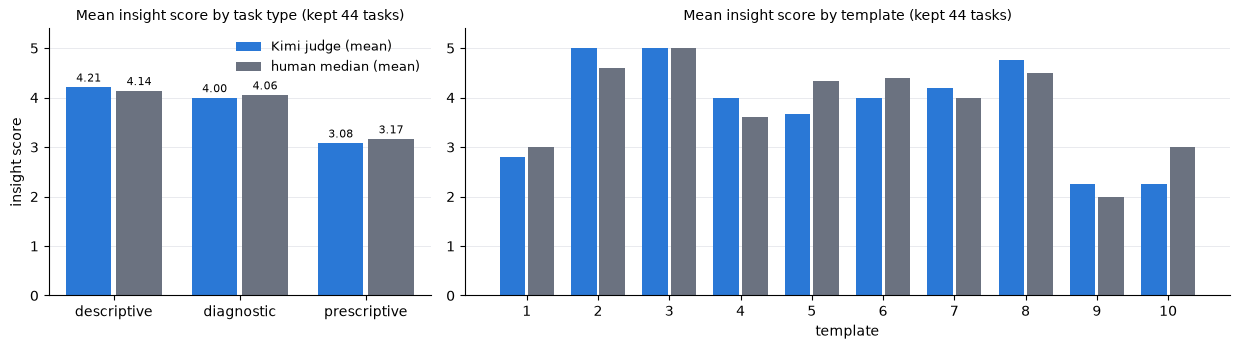

In [14]:
import matplotlib.pyplot as plt

subgroup = pd.DataFrame({'Kimi judge': kimi, 'human median': kept['median'],
                         'template': bias['template'],
                         'task_type': bias['task_type']})
by_type = (subgroup.groupby('task_type')[['Kimi judge', 'human median']].mean()
           .reindex(['descriptive', 'diagnostic', 'prescriptive']))
by_template = subgroup.groupby('template')[['Kimi judge', 'human median']].mean()

KIMI, HUMAN = '#2a78d6', '#6b7280'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.6), width_ratios=[1, 2])
for ax, tbl, title in ((ax1, by_type, 'by task type'),
                       (ax2, by_template, 'by template')):
    x = np.arange(len(tbl))
    bars_k = ax.bar(x - 0.2, tbl['Kimi judge'], 0.36, color=KIMI,
                    label='Kimi judge (mean)')
    bars_h = ax.bar(x + 0.2, tbl['human median'], 0.36, color=HUMAN,
                    label='human median (mean)')
    if ax is ax1:  # direct values on the sparse panel only
        ax.bar_label(bars_k, fmt='%.2f', fontsize=8, padding=2)
        ax.bar_label(bars_h, fmt='%.2f', fontsize=8, padding=2)
    ax.set_xticks(x, tbl.index)
    ax.set_ylim(0, 5.4)
    ax.set_yticks(SCALE)
    ax.grid(axis='y', color='#e5e7eb', lw=0.6)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'Mean insight score {title} (kept 44 tasks)', fontsize=10)
ax1.set_ylabel('insight score')
ax2.set_xlabel('template')
ax1.legend(loc='upper right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

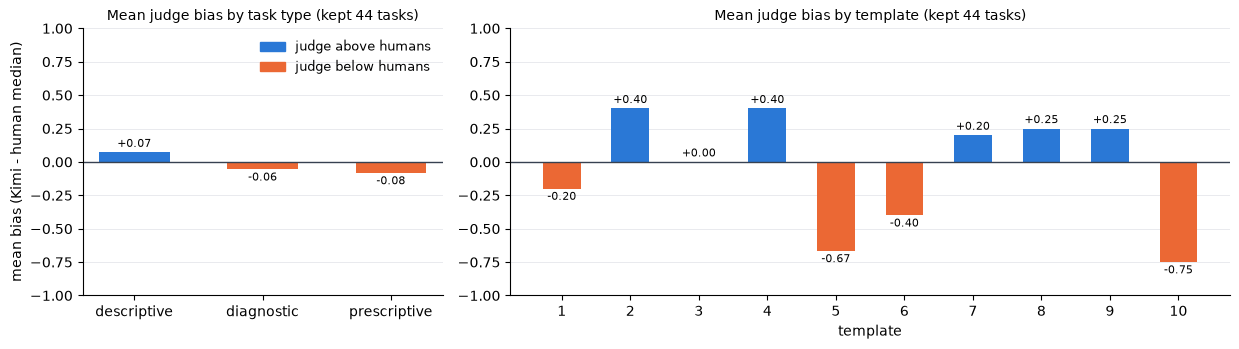

In [15]:
from matplotlib.patches import Patch

bias_by_type = (bias.groupby('task_type')['diff'].mean()
                .reindex(['descriptive', 'diagnostic', 'prescriptive']))
bias_by_template = bias.groupby('template')['diff'].mean()

POS, NEG = '#2a78d6', '#eb6834'  # generous (judge above humans) / harsh (below)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.6), width_ratios=[1, 2])
for ax, tbl, title in ((ax1, bias_by_type, 'by task type'),
                       (ax2, bias_by_template, 'by template')):
    x = np.arange(len(tbl))
    bars = ax.bar(x, tbl, 0.55, color=[POS if v >= 0 else NEG for v in tbl])
    ax.bar_label(bars, fmt='%+.2f', fontsize=8, padding=2)
    ax.axhline(0, color='#374151', lw=1)
    ax.set_xticks(x, tbl.index)
    ax.set_ylim(-1, 1)
    ax.grid(axis='y', color='#e5e7eb', lw=0.6)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'Mean judge bias {title} (kept 44 tasks)', fontsize=10)
ax1.set_ylabel('mean bias (Kimi - human median)')
ax2.set_xlabel('template')
ax1.legend(handles=[Patch(color=POS, label='judge above humans'),
                    Patch(color=NEG, label='judge below humans')],
           loc='upper right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

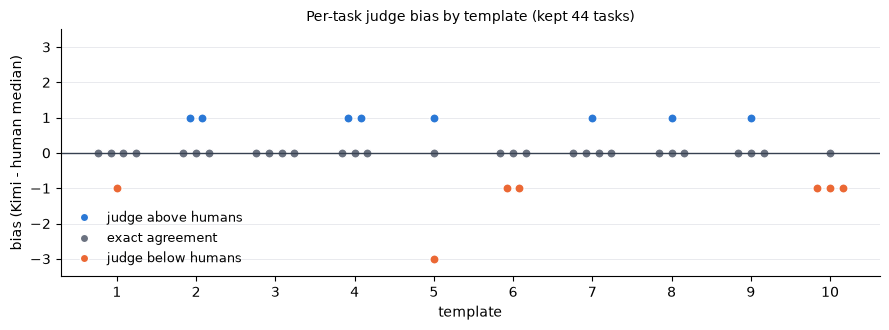

In [16]:
# per-task bias points (up to 5 per template; pruned tasks leave some with fewer),
# tied values spread horizontally so every task stays visible
from matplotlib.lines import Line2D

ZERO = '#6b7280'
fig, ax = plt.subplots(figsize=(9, 3.4))
for t, grp in bias.groupby('template'):
    for v, ties in grp.groupby('diff'):
        n = len(ties)
        for i in range(n):
            ax.scatter(t + (i - (n - 1) / 2) * 0.16, v, s=42,
                       color=POS if v > 0 else (NEG if v < 0 else ZERO),
                       edgecolor='white', lw=0.8, zorder=2)
ax.axhline(0, color='#374151', lw=1)
ax.set_xticks(bias_by_template.index)
ax.set_xlabel('template')
ax.set_ylabel('bias (Kimi - human median)')
lim = bias['diff'].abs().max() + 0.5
ax.set_ylim(-lim, lim)
ax.grid(axis='y', color='#e5e7eb', lw=0.6)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=POS, mec='white',
                          label='judge above humans'),
                   Line2D([], [], marker='o', ls='', color=ZERO, mec='white',
                          label='exact agreement'),
                   Line2D([], [], marker='o', ls='', color=NEG, mec='white',
                          label='judge below humans')],
          loc='lower left', frameon=False, fontsize=9)
ax.set_title('Per-task judge bias by template (kept 44 tasks)', fontsize=10)
plt.tight_layout()
plt.show()